# Notebook 01b - Spline Choreography Kinematics, Jerk-Minimised (QP)

Author: Stellars Henson<br>
Approach: model the full 3 s choreography as a **single C2-continuous trajectory** for one body - Victoria's centre of mass - with position, velocity and acceleration all smooth.  The tangential acceleration along the path is a **cubic spline**; velocity and position are its analytic antiderivatives, so the position trajectory is C4.  The spline knots are placed by **quadratic programming**: minimise the integrated jerk-squared subject to *linear* constraints.

## Model decisions

- **One body only.**  This is a kinematics study of Victoria's CoM.  Andrew's motion is not modelled here.
- **Stationary points at the direction changes.**  At the impact moment (the change of direction at the door) both velocity AND acceleration are effectively zero - the body decelerates to a momentary rest at the door, then reverses.  Likewise the choreography starts and ends at rest.  So there are three stationary points: start (t=0), impact (t=t_impact), end (t=3), each with v=0 and a=0.
- **Pull distance 2.0 m** - the curved-path arc length (corridor diagonal + the body rotation mean the CoM cannot travel a straight line).
- **Forces are computed later, not here.**  The total force at the impact will be the sum of an *impact force* (the collision / body compression) plus an *acceleration force* (Victoria pushing herself off the door and driving with her feet).  Their proportion is a kinematics hyperparameter applied downstream.  This notebook produces only the smooth kinematic trajectory; `a(t)` here is the net kinematic acceleration.

## Outputs

- `reports/figures/01b-path-curve.png` - the curved CoM path in the corridor plane
- `reports/figures/01b-trajectory-splines.png` - position / velocity / acceleration / jerk, all smooth
- `reports/figures/01b-continuity-check.png` - numerical C2 continuity verification
- `reports/figures/01b-yield-study.png` - peak impact force vs body compressive-yield model

In [1]:
# Imports
from __future__ import annotations

import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from rich.console import Console
from rich.panel import Panel
from rich.table import Table

# Project library - the choreography modelling lives in the corridor submodule
from henryk_simulations.corridor import (
    ChoreographyConfig,
    constraints,
    free_parameters,
    impact_singularity,
    solve_choreography,
)
from henryk_simulations.corridor.choreography import YIELD_FACTORS

%load_ext autoreload
%autoreload 2

console = Console()
sns.set_theme(style="whitegrid", context="notebook")

2026-05-17 15:21:40.315 | INFO     | henryk_simulations.config:<module>:40 - PROJ_ROOT path is: /home/lab/workspace/private/henryk/henryk-simulations


In [2]:
SEED = 42
np.random.seed(SEED)

## Kinematics Linear Prototype

Before the smooth spline trajectory, the problem is grounded with the **kinematics linear prototype** - a piecewise-linear acceleration model, the idealised skeleton that the later spline smoothing, integration and QP optimisation refine.  In this reference model the acceleration is a sequence of straight-line ramps and plateaus; integrating once gives a piecewise-quadratic velocity and again a piecewise-cubic position.  The diagram below shows all three.  It is **symbolic** - the impact spike `a_imp` is physically about ten times deeper than `a_max`, so it is drawn off-scale on the acceleration panel to keep the choreography levels visible.  The segment areas are balanced, so velocity returns to zero at the start, at the foot of the impact spike, and at the end.

**Phase 1** (pull to the door):

1. **Start jerk / give** - acceleration ramps linearly from `a = 0` up to `a_max`
2. **Constant acceleration** - plateau at `a_max`
3. **Release** - acceleration ramps `a_max -> 0` over its yield time
4. **Coast** - `a = 0`, the body travels at constant speed
5. **Impact** - a deceleration spike `0 -> a_imp -> 0`, ending when `v = 0`; this spike is the **decoupled singularity**, resolved separately on its own millisecond timeline

**Phase 2** (return from the door):

1. **Reverse jerk** - acceleration ramps from `(a = 0, v = 0)` to the reverse-direction acceleration `a_rev`
2. **Deceleration** - acceleration ramps from `a_rev` through zero to the brake level `a_brk`, then back to `0`, bringing the body to rest (`a = 0, v = 0`)

The ramp corners in this model are sharp - infinite jerk at every breakpoint.  The spline model below replaces each corner with a C2-smooth transition, and the QP places the knots to minimise jerk.  The linear model is the reference the smoothed trajectory is measured against.

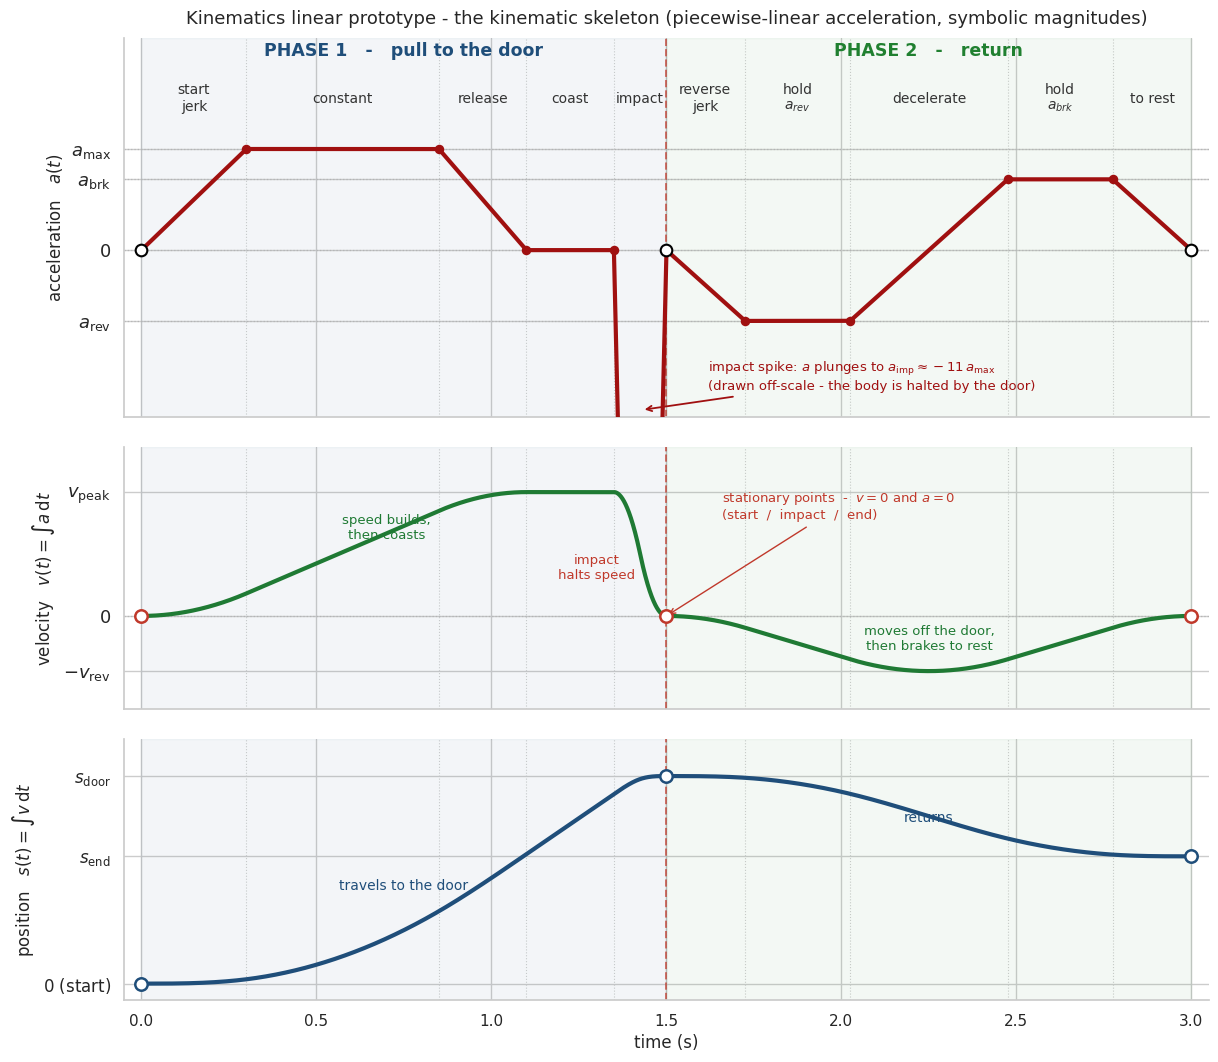

Linear reference model: acceleration (piecewise-linear) integrates to velocity (piecewise-quadratic) and to position (piecewise-cubic). Vertical guides link the same instant across all three panels. Areas balanced so v=0 at the three stationary points. The sharp corners are infinite-jerk - the spline QP below smooths them to C2.


In [3]:
# Linear reference model - piecewise-linear acceleration, SYMBOLIC schematic.
# Areas balanced so velocity returns to zero at every stationary point
# (start, impact, end). Acceleration integrates once to velocity, again to
# position. The impact spike a_imp is ~11x deeper than a_max and is drawn
# off-scale so the choreography levels stay legible. Structure only.
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from pathlib import Path as _Path
_FIG_DIR = _Path("..") / "reports" / "figures"
_FIG_DIR.mkdir(parents=True, exist_ok=True)

# symbolic acceleration levels (illustrative magnitudes)
a_max = 1.00                     # phase-1 peak choreography acceleration
a_rev = -0.70                    # phase-2 reverse-direction acceleration
a_brk = -a_rev                   # phase-2 brake (mirrors a_rev -> phase-2 v balances)

# piecewise-linear acceleration breakpoints (time, accel)
bp_t = [0.00, 0.30, 0.85, 1.10, 1.35, 1.425, 1.50,
        1.725, 2.025, 2.475, 2.775, 3.00]
A_accel = 0.5 * 0.30 * a_max + 0.55 * a_max + 0.5 * 0.25 * a_max
a_imp = -A_accel / (0.5 * 0.15)   # impact depth that cancels the phase-1 accel area
bp_a = [0.0, a_max, a_max, 0.0, 0.0, a_imp, 0.0,
        a_rev, a_rev, a_brk, a_brk, 0.0]

# integrate: a -> v -> s
tg = np.linspace(0, 3.0, 6000)
a_lin = np.interp(tg, bp_t, bp_a)
v_lin = np.concatenate([[0], np.cumsum((a_lin[1:] + a_lin[:-1]) / 2 * np.diff(tg))])
s_lin = np.concatenate([[0], np.cumsum((v_lin[1:] + v_lin[:-1]) / 2 * np.diff(tg))])
t_imp = 1.5
v_imp, s_imp = np.interp(t_imp, tg, v_lin), np.interp(t_imp, tg, s_lin)
v_peak, v_min, s_end = v_lin.max(), v_lin.min(), s_lin[-1]

# segment dividers + labels
seg_bounds = [0.30, 0.85, 1.10, 1.35, 1.50, 1.725, 2.025, 2.475, 2.775]
segments = [(0.15, "start\njerk"), (0.575, "constant"), (0.975, "release"),
            (1.225, "coast"), (1.425, "impact"), (1.61, "reverse\njerk"),
            (1.875, "hold\n$a_{rev}$"), (2.25, "decelerate"),
            (2.625, "hold\n$a_{brk}$"), (2.89, "to rest")]

fig = plt.figure(figsize=(14, 12.5))
gs = GridSpec(3, 1, height_ratios=[1.45, 1.0, 1.0], hspace=0.10)
ax_a = fig.add_subplot(gs[0])
ax_v = fig.add_subplot(gs[1], sharex=ax_a)
ax_s = fig.add_subplot(gs[2], sharex=ax_a)

# shared backdrop: phase tints + segment dividers + impact line
for ax in (ax_a, ax_v, ax_s):
    ax.axvspan(0.0, 1.5, color="#1f4e7a", alpha=0.05)
    ax.axvspan(1.5, 3.0, color="#208030", alpha=0.05)
    for xb in seg_bounds:
        ax.axvline(xb, color="#cfcfcf", ls=":", lw=0.8, zorder=0)
    ax.axvline(1.5, color="#c0392b", ls="--", lw=1.4, alpha=0.7, zorder=1)
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_xlim(-0.05, 3.05)

# ----- ACCELERATION -----
for lvl in (a_max, a_brk, 0.0, a_rev):
    ax_a.axhline(lvl, color="#b0b0b0", ls=":", lw=0.9, alpha=0.8)
ax_a.plot(tg, a_lin, color="#a01010", lw=3.0, solid_joinstyle="round", zorder=4)
ax_a.scatter(bp_t, bp_a, color="#a01010", s=34, zorder=5)   # knots
ax_a.scatter([0, 1.5, 3.0], [0, 0, 0], facecolor="white", edgecolor="black",
             s=70, lw=1.5, zorder=6)
ax_a.set_yticks([a_rev, 0.0, a_brk, a_max])
ax_a.set_yticklabels([r"$a_\mathrm{rev}$", "$0$", r"$a_\mathrm{brk}$",
                      r"$a_\mathrm{max}$"], fontsize=13)
ax_a.set_ylim(a_rev - 0.95, a_max * 2.10)
ax_a.set_ylabel("acceleration   $a(t)$", fontsize=12)
# segment labels in a band above the curve
for tx, lab in segments:
    ax_a.text(tx, a_max * 1.50, lab, ha="center", va="center", fontsize=10,
              color="#333333")
# phase headers
ax_a.text(0.75, a_max * 1.92, "PHASE 1   -   pull to the door", ha="center",
          fontsize=12.5, fontweight="bold", color="#1f4e7a")
ax_a.text(2.25, a_max * 1.92, "PHASE 2   -   return", ha="center",
          fontsize=12.5, fontweight="bold", color="#208030")
# impact off-scale callout
ax_a.annotate(r"impact spike: $a$ plunges to $a_\mathrm{imp}\approx-11\,a_\mathrm{max}$"
              "\n(drawn off-scale - the body is halted by the door)",
              xy=(1.43, a_rev - 0.88), xytext=(1.62, a_rev - 0.55),
              fontsize=9.5, color="#a01010", va="center",
              arrowprops=dict(arrowstyle="->", color="#a01010", lw=1.3))
ax_a.set_title("Kinematics linear prototype - the kinematic skeleton "
               "(piecewise-linear acceleration, symbolic magnitudes)",
               fontsize=13, pad=10)

# ----- VELOCITY -----
ax_v.axhline(0.0, color="#b0b0b0", ls=":", lw=0.9, alpha=0.8)
ax_v.plot(tg, v_lin, color="#1f7a34", lw=3.0, zorder=4)
ax_v.scatter([0, t_imp, 3.0], [0, v_imp, 0], facecolor="white",
             edgecolor="#c0392b", s=80, lw=1.8, zorder=6)
ax_v.set_yticks([v_min, 0.0, v_peak])
ax_v.set_yticklabels([r"$-v_\mathrm{rev}$", "$0$", r"$v_\mathrm{peak}$"],
                     fontsize=13)
ax_v.set_ylabel(r"velocity   $v(t)=\int a\,\mathrm{d}t$", fontsize=12)
ax_v.set_ylim(v_min - 0.25, v_peak + 0.30)
ax_v.text(0.70, v_peak * 0.62, "speed builds,\nthen coasts", ha="center",
          fontsize=9.5, color="#1f7a34")
ax_v.text(1.30, v_peak * 0.30, "impact\nhalts speed", ha="center", fontsize=9.5,
          color="#c0392b")
ax_v.text(2.25, v_min * 0.62, "moves off the door,\nthen brakes to rest",
          ha="center", fontsize=9.5, color="#1f7a34")
ax_v.annotate("stationary points  -  $v=0$ and $a=0$\n(start  /  impact  /  end)",
              xy=(t_imp, v_imp), xytext=(1.66, v_peak * 0.78), fontsize=9.5,
              color="#c0392b", arrowprops=dict(arrowstyle="->", color="#c0392b"))

# ----- POSITION -----
ax_s.plot(tg, s_lin, color="#1f4e7a", lw=3.0, zorder=4)
ax_s.scatter([0, t_imp, 3.0], [0, s_imp, s_end], facecolor="white",
             edgecolor="#1f4e7a", s=80, lw=1.8, zorder=6)
ax_s.set_yticks([0.0, s_end, s_imp])
ax_s.set_yticklabels(["$0$ (start)", r"$s_\mathrm{end}$", r"$s_\mathrm{door}$"],
                     fontsize=12)
ax_s.set_ylabel(r"position   $s(t)=\int v\,\mathrm{d}t$", fontsize=12)
ax_s.set_ylim(-0.08 * s_imp, s_imp * 1.18)
ax_s.set_xlabel("time (s)", fontsize=12)
ax_s.text(0.75, s_imp * 0.45, "travels to the door", ha="center", fontsize=10,
          color="#1f4e7a")
ax_s.text(2.25, s_imp * 0.78, "returns", ha="center", fontsize=10,
          color="#1f4e7a")

for ax in (ax_a, ax_v):
    plt.setp(ax.get_xticklabels(), visible=False)

fig.savefig(_FIG_DIR / "01b-linear-reference-model.png", dpi=150,
            bbox_inches="tight")
plt.show()
print("Linear reference model: acceleration (piecewise-linear) integrates to "
      "velocity (piecewise-quadratic) and to position (piecewise-cubic). "
      "Vertical guides link the same instant across all three panels. Areas "
      "balanced so v=0 at the three stationary points. The sharp corners are "
      "infinite-jerk - the spline QP below smooths them to C2.")

### Prototype variables - inputs and outputs

The kinematics linear prototype names every variable the model works with and fixes the role each one plays. There are four kinds:

- **Hyperparameter** - a value the analyst sets; the model takes it as given
- **Boundary condition** - a value pinned at a phase boundary; these become the equality constraints each phase QP must satisfy
- **Optimisation result** - a value a phase QP produces; emergent from minimising jerk under the constraints
- **Singularity output** - a value the decoupled impact model returns, computed from the closing velocity on its own millisecond timeline

| Symbol | Quantity | Role | Value / origin |
|---|---|---|---|
| $T$ | total choreography time | hyperparameter | 3.0 s, fixed at the claim |
| $t_1$ | phase-1 duration (phase split) | hyperparameter | 1.5 s, configurable |
| $L_\text{arc}$ | phase-1 curved-path length | hyperparameter | 2.0 m, corridor geometry |
| $\Delta s_2$ | phase-2 return translation | hyperparameter | 0.50 m |
| $d,\;k$ | body compression, stiffness | hyperparameter | 3 cm, $8\times10^5$ N/m (rigid door, FEA body) |
| $a(0),\,v(0),\,s(0)$ | phase-1 start | boundary condition | all $0$ - at rest at the origin |
| $a(t_1)$ | phase-1 end (contact) | boundary condition | $0$ - released, coasting into the door |
| $s(t_1)$ | position at contact | boundary condition | $=L_\text{arc}$ |
| $v,\,a$ at phase-2 start | post-singularity rest | boundary condition | both $0$ - body at rest after the impact |
| $v(T),\,a(T)$ | phase-2 end | boundary condition | both $0$ - at rest |
| $s(T)$ | final position | boundary condition | $=L_\text{arc}-\Delta s_2$ |
| $\mathbf{a}_1,\,\mathbf{a}_2$ | per-phase spline knot vectors | optimisation result | the QP decision variables |
| $v_\text{close}$ | closing velocity at contact | optimisation result | emergent - phase-1 terminal velocity, left free in the QP |
| $a_\text{max}$ | phase-1 peak acceleration | optimisation result | emergent |
| $v_\text{rev}$ | phase-2 peak return speed | optimisation result | emergent |
| $a_\text{rev},\,a_\text{brk}$ | phase-2 accel / brake peaks | optimisation result | emergent |
| $j_\text{peak}$ | peak jerk, per phase | optimisation result | emergent |
| $a_\text{imp}$ | impact peak deceleration | singularity output | from $v_\text{close}$, $d$, yield model |
| $\tau_\text{imp}$ | impact duration | singularity output | $\approx 2d/v_\text{close}$, a few tens of ms |
| $F_\text{imp}$ | impact force | singularity output | $m\,a_\text{imp}$ |

Each phase QP takes the hyperparameters and boundary conditions and returns the optimisation results. The closing velocity $v_\text{close}$ is then handed to the decoupled impact singularity, which returns its own outputs on a separate millisecond timeline.

The permissible literature bands for the optimisation-result parameters - and the exclusion zones they carve in the solution manifold - are derived in the **Exclusion Zones** section below.

## Configuration - KINEMATICS

Single source of truth.  The yield-time block characterises the smooth transitions; the body-compression block feeds the downstream force calculation, not the trajectory itself.

In [4]:
KINEMATICS = {
    "total_time_s": 3.0,
    # Phase durations are NOT free hyperparameters. The phase-2 duration is
    # LOCKED by its 180 deg rotation at the midpoint of the elite and
    # population yaw-rate floors (see the Phase-2 Duration Constraint
    # section); phase-1 duration = total_time_s - phase2_duration_s. Both
    # are written into KINEMATICS["time"] by that section.
    "phase1_pull": {
        "path_arc_length_m": 2.0,     # curved-path arc length, corridor door-to-door
        "lateral_offset_m": 0.25,     # diagonal sag of the curved CoM path
        "rotation_rad": math.pi,      # 180 deg half-rotation
        # terminal (closing) velocity is NOT pinned - it emerges from the
        # jerk-minimal QP as the speed needed to cover the arc in phase 1.
    },
    "phase2_return": {
        "translation_m": 0.50,        # 50 cm back from the door
        "rotation_rad": math.pi,      # another 180 deg
        # rest-to-rest, self-propelled (push off the door + feet).
    },
    "impact_singularity": {
        # The impact is a DECOUPLED SINGULARITY: a separate impulsive event
        # resolved on its own millisecond timeline, NOT on the 3 s axis. It
        # takes the phase-1 closing velocity v_close as input and returns
        # the body to rest. On the 3 s axis it is a point - a velocity
        # discontinuity v_close -> 0 at t = phase1_duration.
        "door": "rigid",              # no door give; deceleration is body compression
        "body_compression_m": 0.030,  # rigid door => all compression is the body
        "body_stiffness_N_per_m": 8.0e5,
    },
    "bodies": {
        "victoria_mass_kg": 70.0,
        "victoria_yaw_inertia_kgm2": 1.4,
    },
    "force_model": {
        # Applied DOWNSTREAM. Total force at impact = impact_force (the
        # singularity) + acceleration_force (Victoria's own propulsion).
        # accel_force_fraction is the propulsion share. Swept later.
        "accel_force_fraction": 0.5,
    },
    "spline": {
        "n_knots_per_phase": 31,
        "n_eval": 4000,
    },
    "paths": {"fig_dir": Path("..") / "reports" / "figures"},
}

FIG_DIR = KINEMATICS["paths"]["fig_dir"]
FIG_DIR.mkdir(parents=True, exist_ok=True)

tbl = Table(show_header=False, box=None, padding=(0, 2))
tbl.add_column("k", style="bold cyan"); tbl.add_column("v")
for section, items in KINEMATICS.items():
    if isinstance(items, dict):
        tbl.add_row(f"[bold magenta]{section}[/bold magenta]", "")
        for k, v in items.items():
            tbl.add_row(f"  {k}", f"[white]{v}[/white]")
    else:
        tbl.add_row(f"[bold magenta]{section}[/bold magenta]", f"[white]{items}[/white]")
console.print(Panel(tbl, title="[bold green]KINEMATICS[/bold green]", border_style="green"))

╭────────────────────────────────────────────────── KINEMATICS ───────────────────────────────────────────────────╮
│   total_time_s                   3.0                                                                            │
│   phase1_pull                                                                                                   │
│     path_arc_length_m            2.0                                                                            │
│     lateral_offset_m             0.25                                                                           │
│     rotation_rad                 3.141592653589793                                                              │
│   phase2_return                                                                                                 │
│     translation_m                0.5                                                                            │
│     rotation_rad                 3.141592653589793                                                              │
│   impact_singularity                                                                                            │
│     door                         rigid                                                                          │
│     body_compression_m           0.03                                                                           │
│     body_stiffness_N_per_m       800000.0                                                                       │
│   bodies                                                                                                        │
│     victoria_mass_kg             70.0                                                                           │
│     victoria_yaw_inertia_kgm2    1.4                                                                            │
│   force_model                                                                                                   │
│     accel_force_fraction         0.5                                                                            │
│   spline                                                                                                        │
│     n_knots_per_phase            31                                                                             │
│     n_eval                       4000                                                                           │
│   paths                                                                                                         │
│     fig_dir                      ../reports/figures                                                             │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

## Phase-2 Duration Constraint - the 180 Degree Rotation

Before the full kinematics study, one constraint on phase 2 can be settled on its own.  Phase 2 contains a **180 degree yaw rotation**, and rotating a human body takes time - that time is a floor on the phase-2 duration, fixed before any trajectory is solved.

Treat the body, turning about its vertical axis, as a rigid body with a yaw **moment of inertia** $I$.  Plagenhoef, Evans & Abdelnour (1983) give the whole-body yaw moment of inertia about the centre of mass as about 1.5 kg m$^2$ for a 75 kg adult; scaled to a 70 kg body this notebook assumes $I = 1.4$ kg m$^2$.

**Two separate turns, not one.**  Phase 1 rotates the body 180 degrees to strike the door back-first; phase 2 rotates it another 180 degrees to the front-first configuration Cecilia described.  The body's rotation halts at the impact - the collision with the rigid door arrests the spin just as it arrests the translation, and a clean back-first impact requires the turn to be already complete ($\omega\approx 0$) at contact.  So each phase is its own rest-to-rest turn, accelerating from $\omega=0$, building angular momentum $L=I\,\omega$ under a torque $\tau=I\,\alpha$, then decelerating back to $\omega=0$.

For a symmetric accelerate-decelerate the peak yaw rate is $\omega_\text{peak}=2\,\Delta\theta/t_2=2\pi/t_2$, so a cap on $\omega_\text{peak}$ becomes a floor on $t_2$.  Hodgson, Lewis & Drury (2008) measured the peak yaw rate of a voluntary 180 degree standing pivot at 3.5 rad/s (SD 1.0):

- **population** rate 3.5 rad/s  ->  $t_2 \ge 2\pi/3.5 = 1.80$ s
- **elite** rate 5.5 rad/s (mean + 2 SD)  ->  $t_2 \ge 2\pi/5.5 = 1.14$ s

The simulation **locks the phase-2 duration at the midpoint of these two floors**, $t_2 \approx 1.47$ s, and adopts it as the lower-bound constraint - neither the generous elite figure nor the strict population figure.  Phase 1 then takes the remaining $t_1 = 3 - t_2 \approx 1.53$ s.  Under the yaw-rate cap a single continuous 360 degree turn would need the same total time; the two separate turns differ only in demanding roughly twice the angular acceleration, since each half has half the time to spin up.

This is also why the kinematics study **bundles the rotation with the translation** rather than sequencing them.  With the two 180 degree turns alone consuming 2.94 s of the 3 s budget, a sequential rotate-then-translate timeline cannot fit - the rotations would leave almost nothing for the 2 m pull and the 0.5 m return.  The timeline holds only if each phase performs its turn and its translation **concurrently**, over the same interval.  Bundling them is the most charitable reading consistent with the lower-bound estimation; sequencing them would put the choreography over budget before the translation began.

**References**: Plagenhoef, Evans & Abdelnour (1983) - whole-body yaw moment of inertia; Hodgson, Lewis & Drury (2008) - peak yaw rate of a voluntary 180 degree standing pivot.  Both are archived under `references/literature/`.

Assumed human-body yaw moment of inertia: I = 1.4 kg m^2 (Plagenhoef et al. 1983, scaled to 70 kg)

Phase-2 180 deg rotation, rest-to-rest - yaw-rate duration floors (Hodgson et al. 2008):

population rate 3.5 rad/s  ->  t2 >= 1.80 s

elite rate      5.5 rad/s  ->  t2 >= 1.14 s

LOCKED phase-2 duration  t2 = 1.469 s (midpoint)  ->  phase-1  t1 = 1.531 s

at the lock: yaw rate 4.28 rad/s, accel 5.82 rad/s^2, torque 8.2 N m, angular momentum 5.99 kg m^2/s, rotational 
KE 12.8 J

phase 1 carries the same 180 deg turn: the two rotations alone consume 2.94 s of the 3.0 s budget at the locked 
rate (3.59 s at the population rate) - leaving almost nothing for the translation.

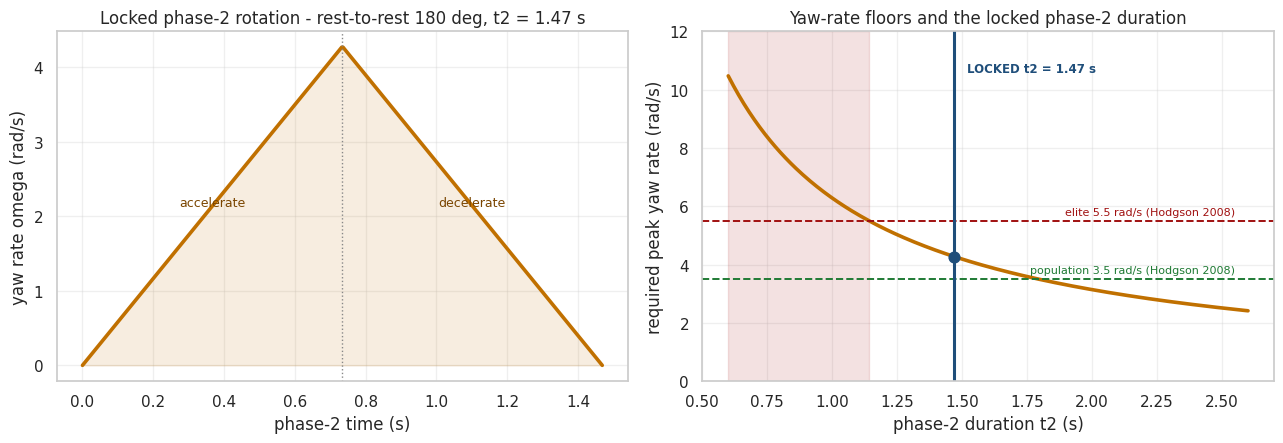

In [5]:
# Phase-2 duration constraint from the 180 deg yaw rotation.
# The body is assumed a rigid body with a human yaw moment of inertia.
I_YAW = KINEMATICS["bodies"]["victoria_yaw_inertia_kgm2"]   # 1.4 kg m^2
DTHETA2 = KINEMATICS["phase2_return"]["rotation_rad"]       # pi rad (180 deg)
T_TOTAL = KINEMATICS["total_time_s"]
# Peak yaw rate of a voluntary 180 deg standing pivot (Hodgson, Lewis &
# Drury 2008): mean 3.5 rad/s, SD 1.0. Population = mean; elite = mean + 2 SD.
OMEGA_POPULATION = 3.5
OMEGA_ELITE = 5.5


def omega_peak_rotation(t2, dtheta=DTHETA2):
    """Peak yaw rate of a rest-to-rest rotation of dtheta in time t2.
    Symmetric accelerate-decelerate: dtheta = omega_peak * t2 / 2."""
    return 2.0 * dtheta / t2


# duration floors: omega_peak <= omega_max  ->  t2 >= 2*dtheta/omega_max
t2_floor_population = 2.0 * DTHETA2 / OMEGA_POPULATION
t2_floor_elite = 2.0 * DTHETA2 / OMEGA_ELITE
# LOCK the phase-2 duration at the midpoint of the two floors - the
# lower-bound constraint adopted for the simulation.
t2_lock = 0.5 * (t2_floor_population + t2_floor_elite)
t1_lock = T_TOTAL - t2_lock
KINEMATICS["time"] = {"phase1_duration_s": t1_lock, "phase2_duration_s": t2_lock}

# rotational dynamics at the locked phase-2 duration
omega_lock = omega_peak_rotation(t2_lock)
alpha_lock = 4.0 * DTHETA2 / t2_lock**2
torque_lock = I_YAW * alpha_lock
L_lock = I_YAW * omega_lock
KE_rot = 0.5 * I_YAW * omega_lock**2

console.print(f"Assumed human-body yaw moment of inertia: I = {I_YAW} kg m^2 "
              f"(Plagenhoef et al. 1983, scaled to 70 kg)")
console.print(f"Phase-2 180 deg rotation, rest-to-rest - yaw-rate duration floors "
              f"(Hodgson et al. 2008):")
console.print(f"  population rate {OMEGA_POPULATION} rad/s  ->  t2 >= "
              f"{t2_floor_population:.2f} s")
console.print(f"  elite rate      {OMEGA_ELITE} rad/s  ->  t2 >= "
              f"{t2_floor_elite:.2f} s")
console.print(f"  [bold]LOCKED phase-2 duration  t2 = {t2_lock:.3f} s[/bold] "
              f"(midpoint)  ->  phase-1  t1 = {t1_lock:.3f} s")
console.print(f"  at the lock: yaw rate {omega_lock:.2f} rad/s, accel "
              f"{alpha_lock:.2f} rad/s^2, torque {torque_lock:.1f} N m, "
              f"angular momentum {L_lock:.2f} kg m^2/s, rotational KE "
              f"{KE_rot:.1f} J")
console.print(f"  [yellow]phase 1 carries the same 180 deg turn: the two "
              f"rotations alone consume {2*t2_lock:.2f} s of the {T_TOTAL:.1f} s "
              f"budget at the locked rate ({2*t2_floor_population:.2f} s at the "
              f"population rate) - leaving almost nothing for the translation."
              f"[/yellow]")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
# (a) the rest-to-rest turn at the locked phase-2 duration
tt = np.linspace(0, t2_lock, 400)
omega_t = np.where(tt <= t2_lock / 2, alpha_lock * tt, alpha_lock * (t2_lock - tt))
axes[0].plot(tt, omega_t, color="#c07000", lw=2.6)
axes[0].fill_between(tt, 0, omega_t, color="#c07000", alpha=0.12)
axes[0].axvline(t2_lock / 2, color="#888888", ls=":", lw=1)
axes[0].text(t2_lock * 0.25, omega_lock * 0.5, "accelerate", ha="center",
             fontsize=9, color="#7a4500")
axes[0].text(t2_lock * 0.75, omega_lock * 0.5, "decelerate", ha="center",
             fontsize=9, color="#7a4500")
axes[0].set_xlabel("phase-2 time (s)")
axes[0].set_ylabel("yaw rate omega (rad/s)")
axes[0].set_title(f"Locked phase-2 rotation - rest-to-rest 180 deg, "
                  f"t2 = {t2_lock:.2f} s")
axes[0].grid(True, alpha=0.3)
# (b) required peak yaw rate vs phase-2 duration, with the floors and the lock
t2v = np.linspace(0.6, 2.6, 300)
axes[1].plot(t2v, omega_peak_rotation(t2v), color="#c07000", lw=2.6)
axes[1].axhline(OMEGA_ELITE, color="#a01010", ls="--", lw=1.4)
axes[1].axhline(OMEGA_POPULATION, color="#1f7a34", ls="--", lw=1.4)
axes[1].axvline(t2_lock, color="#1f4e7a", lw=2.2)
axes[1].scatter([t2_lock], [omega_lock], color="#1f4e7a", s=60, zorder=5)
axes[1].axvspan(t2v[0], t2_floor_elite, color="#a01010", alpha=0.12)
axes[1].text(2.55, OMEGA_ELITE + 0.2, "elite 5.5 rad/s (Hodgson 2008)",
             ha="right", fontsize=8, color="#a01010")
axes[1].text(2.55, OMEGA_POPULATION + 0.2, "population 3.5 rad/s (Hodgson 2008)",
             ha="right", fontsize=8, color="#1f7a34")
axes[1].text(t2_lock + 0.05, 10.6, f"LOCKED t2 = {t2_lock:.2f} s",
             fontsize=8.5, color="#1f4e7a", fontweight="bold")
axes[1].set_xlabel("phase-2 duration t2 (s)")
axes[1].set_ylabel("required peak yaw rate (rad/s)")
axes[1].set_title("Yaw-rate floors and the locked phase-2 duration")
axes[1].set_ylim(0, 12)
axes[1].grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "01b-phase2-rotation.png", dpi=140, bbox_inches="tight")
plt.show()

## Curved CoM Path

Victoria's centre of mass does not travel a straight line - the corridor geometry has a diagonal offset and a body rotating 180 deg sweeps its CoM along a curve.  We model the path as a smooth 2D curve (quadratic Bezier) with **arc length 2.0 m** - the distance the CoM actually travels.

Curved path arc length: 2.000 m  (straight-line 1.919 m)

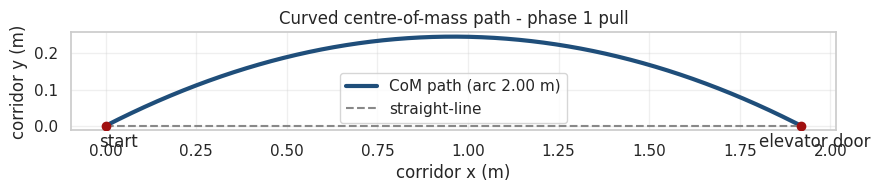

In [6]:
p1 = KINEMATICS["phase1_pull"]
L_arc = p1["path_arc_length_m"]
sag = p1["lateral_offset_m"]

P0 = np.array([0.0, 0.0])
P1 = np.array([1.95, 0.0])
Pc = np.array([0.975, 2.0 * sag])

u = np.linspace(0, 1, 4000)
bez = (1-u)[:, None]**2 * P0 + 2*(1-u)[:, None]*u[:, None] * Pc + u[:, None]**2 * P1
seg = np.sqrt(np.sum(np.diff(bez, axis=0)**2, axis=1))
arc = np.concatenate([[0], np.cumsum(seg)])
scale = L_arc / arc[-1]
bez *= scale
arc *= scale

console.print(f"Curved path arc length: {arc[-1]:.3f} m  "
              f"(straight-line {np.linalg.norm(P1-P0)*scale:.3f} m)")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(bez[:, 0], bez[:, 1], color="#1f4e7a", lw=3, label=f"CoM path (arc {arc[-1]:.2f} m)")
ax.plot([P0[0]*scale, P1[0]*scale], [0, 0], "--", color="#888", label="straight-line")
ax.scatter([P0[0]*scale, P1[0]*scale], [0, 0], color="#a01010", zorder=5)
ax.annotate("start", P0*scale, textcoords="offset points", xytext=(-5, -15))
ax.annotate("elevator door", P1*scale, textcoords="offset points", xytext=(-30, -15))
ax.set_aspect("equal")
ax.set_xlabel("corridor x (m)"); ax.set_ylabel("corridor y (m)")
ax.set_title("Curved centre-of-mass path - phase 1 pull")
ax.legend(); ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "01b-path-curve.png", dpi=140, bbox_inches="tight")
plt.show()

## Free Parameters and Constraints

The choreography modelling lives in `henryk_simulations.corridor.choreography`; this notebook is a thin client over it.

The tangential acceleration `a(t)` is a **quintic spline** through the linear-prototype control points.  At each control point the value, the 1st derivative (jerk) and the 2nd derivative (snap) are **free parameters**; the optimiser sets them to minimise the integral of jerk squared.  The impact-singularity duration is a further parameter, tied to the body compression.

The **constraints** are of two kinds.  **Equality** constraints are the scenario boundary conditions.  **Inequality** constraints are the biomechanical production limits - the exclusion zones - banned from the optimisation manifold by construction; each carries its literature **source**.

In [7]:
# The phase-2 duration is the value locked by the rotation constraint above.
CHOREO = ChoreographyConfig(phase2_duration=t2_lock)
console.print(f"Choreography config: phase 1 = {CHOREO.phase1_duration:.3f} s, "
              f"phase 2 = {CHOREO.phase2_duration:.3f} s (locked), "
              f"arc = {CHOREO.arc_length} m, return = {CHOREO.return_translation} m")

fp = Table(title="[bold]Free parameters - the optimisation variables[/bold]",
           show_header=True, header_style="bold cyan")
fp.add_column("Parameter"); fp.add_column("Symbol")
fp.add_column("Count", justify="right"); fp.add_column("Bounds", justify="right")
fp.add_column("Unit")
for p in free_parameters(CHOREO):
    lo = "-inf" if not np.isfinite(p.lower) else f"{p.lower:.3g}"
    hi = "+inf" if not np.isfinite(p.upper) else f"{p.upper:.3g}"
    fp.add_row(p.name, p.symbol, str(p.count), f"[{lo}, {hi}]", p.unit)
console.print(fp)

ct = Table(title="[bold]Constraints - boundary conditions and production limits[/bold]",
           show_header=True, header_style="bold cyan")
ct.add_column("Constraint"); ct.add_column("Kind")
ct.add_column("Expression"); ct.add_column("Source")
for c in constraints(CHOREO):
    tag = "[green]equality[/]" if c.kind == "equality" else "[yellow]inequality[/]"
    ct.add_row(c.name, tag, c.expression, c.source)
console.print(ct)

Choreography config: phase 1 = 1.531 s, phase 2 = 1.469 s (locked), arc = 2.0 m, return = 0.5 m

                Free parameters - the optimisation variables                
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Parameter                   ┃ Symbol  ┃ Count ┃           Bounds ┃ Unit  ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ control-point acceleration  │ a_i     │    12 │      [-5.5, 5.5] │ m/s^2 │
│ control-point jerk          │ j_i     │    12 │        [-50, 50] │ m/s^3 │
│ control-point snap          │ s_i     │    12 │     [-inf, +inf] │ m/s^4 │
│ impact-singularity duration │ tau_imp │     1 │ [0.0163, 0.0408] │ s     │
└─────────────────────────────┴─────────┴───────┴──────────────────┴───────┘

                              Constraints - boundary conditions and production limits                              
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Constraint                    ┃ Kind       ┃ Expression                      ┃ Source                           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ phase-1 smooth start          │ equality   │ a(0) = 0                        │ scenario boundary condition      │
│ phase-1 reaches the door      │ equality   │ s(t1) = 2.0 m                   │ scenario boundary condition      │
│ phase-1 released at contact   │ equality   │ a(t1) = 0                       │ scenario boundary condition      │
│ phase-2 smooth push-off       │ equality   │ a(0) = 0                        │ scenario boundary condition      │
│ phase-2 return distance       │ equality   │ s(t2) = -0.5 m                  │ scenario boundary condition      │
│ phase-2 ends at rest          │ equality   │ v(t2) = 0                       │ scenario boundary condition      │
│ phase-2 zero end acceleration │ equality   │ a(t2) = 0                       │ scenario boundary condition      │
│ peak acceleration limit       │ inequality │ |a(t)| <= 5.5 m/s^2             │ Mero, Komi & Gregor 1992 - peak  │
│                               │            │                                 │ CoM acceleration, elite + 1 SD   │
│ peak jerk limit               │ inequality │ |jerk(t)| <= 50.0 m/s^3         │ Maffiuletti et al. 2016; Aagaard │
│                               │            │                                 │ et al. 2002 - rate of force      │
│                               │            │                                 │ development (jerk = force rate / │
│                               │            │                                 │ mass)                            │
│ impact-duration ceiling       │ inequality │ tau_imp = 2 d / v_close,  d <=  │ body-compression range - Lobdell │
│                               │            │ 5 cm                            │ 1973; Kroell 1971; Kemper et al. │
│                               │            │                                 │ 2014                             │
└───────────────────────────────┴────────────┴─────────────────────────────────┴──────────────────────────────────┘

## Kinematics Run

`solve_choreography` solves the two-phase quintic-spline QP - phase 1 approach, the decoupled impact singularity, phase 2 return - and the notebook displays the result.  Constraint compliance and C2 continuity are verified by 23 guards in `tests/test_choreography.py`.

       Decoupled-singularity choreography - solved        
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Quantity                    ┃                    Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Phase 1 (approach) duration │                  1.531 s │
│ Phase 2 (return) duration   │                  1.469 s │
│ Closing velocity v_close    │                2.450 m/s │
│ Phase-1 peak acceleration   │    2.468 m/s^2  (0.25 g) │
│ Phase-2 peak acceleration   │    1.343 m/s^2  (0.14 g) │
│ Phase-1 peak jerk           │               7.69 m/s^3 │
│ Phase-2 peak jerk           │               8.41 m/s^3 │
│ Production limits active    │ no (optimum is interior) │
│ Impact singularity duration │                  24.5 ms │
│ Impact body compression     │                  3.00 cm │
│ Impact kinetic energy       │                    210 J │
│ Impact impulse              │                  171 N s │
└─────────────────────────────┴──────────────────────────┘

    Impact singularity - force across yield models    
             (v_close=2.45 m/s, d=3.0 cm)             
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━┓
┃ Yield model              ┃ a_peak (g) ┃ Force (kN) ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━┩
│ constant (rigid-plastic) │       10.2 │       7.00 │
│ half-sine                │       16.0 │      10.99 │
│ smootherstep             │       19.2 │      13.17 │
│ linear elastic spring    │       20.4 │      14.01 │
│ Hertzian (n=1.5)         │       25.5 │      17.51 │
└──────────────────────────┴────────────┴────────────┘

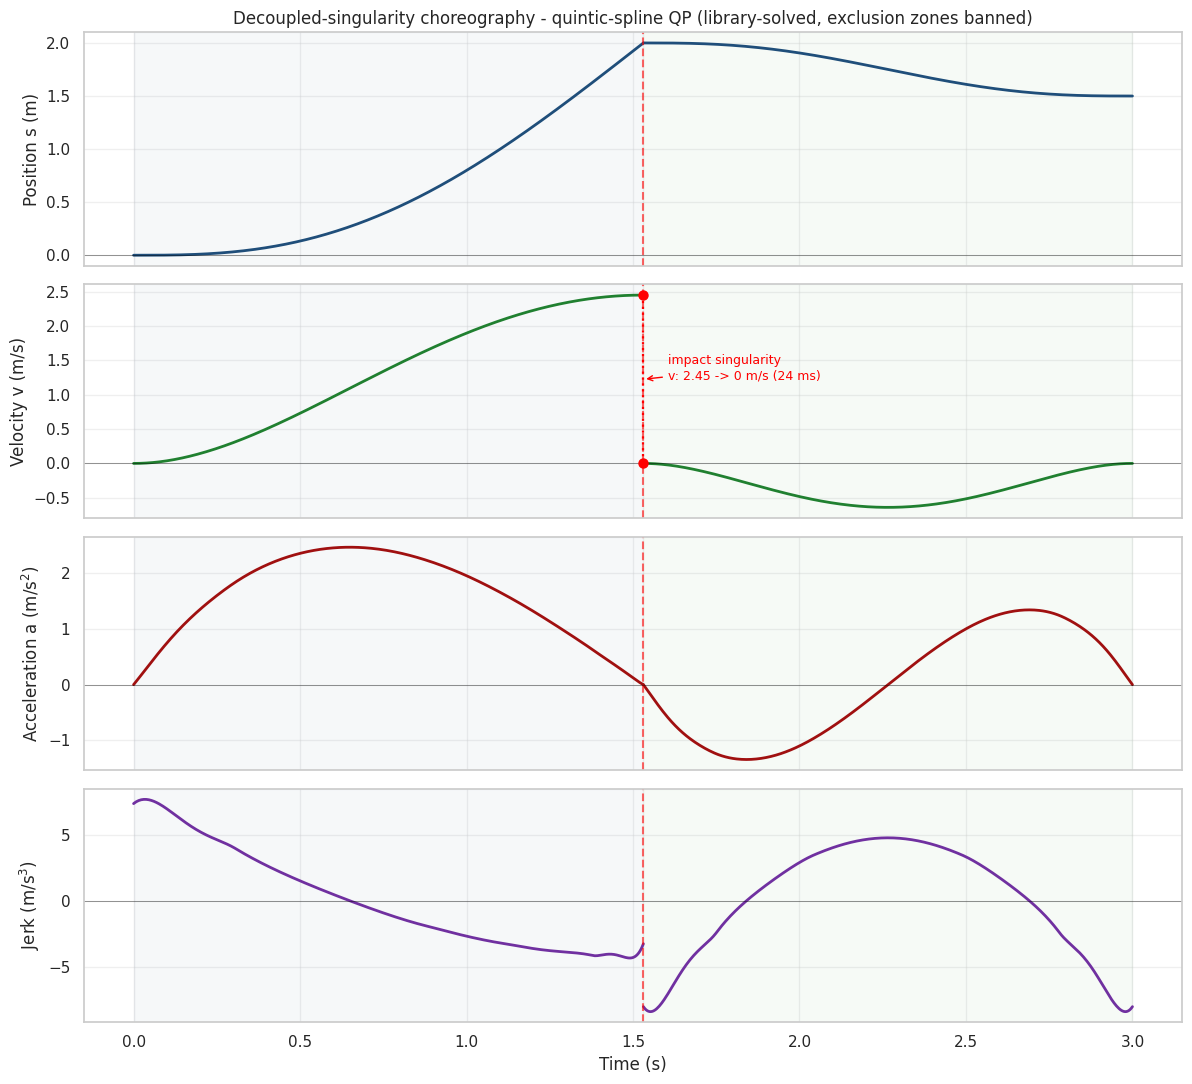

In [8]:
result = solve_choreography(CHOREO)
p1, p2, sing = result.phase1, result.phase2, result.singularity
G = 9.80665

rt = Table(title="[bold]Decoupled-singularity choreography - solved[/bold]",
           show_header=True, header_style="bold cyan")
rt.add_column("Quantity"); rt.add_column("Value", justify="right")
rt.add_row("Phase 1 (approach) duration", f"{p1.duration:.3f} s")
rt.add_row("Phase 2 (return) duration", f"{p2.duration:.3f} s")
rt.add_row("Closing velocity v_close", f"[bold green]{result.v_close:.3f} m/s[/]")
rt.add_row("Phase-1 peak acceleration",
           f"{p1.a_peak:.3f} m/s^2  ({p1.a_peak / G:.2f} g)")
rt.add_row("Phase-2 peak acceleration",
           f"{p2.a_peak:.3f} m/s^2  ({p2.a_peak / G:.2f} g)")
rt.add_row("Phase-1 peak jerk", f"{p1.jerk_peak:.2f} m/s^3")
rt.add_row("Phase-2 peak jerk", f"{p2.jerk_peak:.2f} m/s^3")
rt.add_row("Production limits active",
           "yes" if result.bounds_active else "no (optimum is interior)")
rt.add_row("Impact singularity duration", f"{sing.tau_imp * 1e3:.1f} ms")
rt.add_row("Impact body compression", f"{sing.compression * 1e2:.2f} cm")
rt.add_row("Impact kinetic energy", f"{sing.kinetic_energy:.0f} J")
rt.add_row("Impact impulse", f"{sing.impulse:.0f} N s")
console.print(rt)

# impact force across yield models
yt = Table(title=f"[bold]Impact singularity - force across yield models "
           f"(v_close={result.v_close:.2f} m/s, d={sing.compression * 1e2:.1f} cm)[/bold]",
           show_header=True, header_style="bold cyan")
yt.add_column("Yield model"); yt.add_column("a_peak (g)", justify="right")
yt.add_column("Force (kN)", justify="right")
for model in YIELD_FACTORS:
    s_m = impact_singularity(result.v_close, sing.tau_imp, CHOREO, model)
    yt.add_row(model, f"{s_m.a_peak_g:.1f}", f"{s_m.force_peak / 1e3:.2f}")
console.print(yt)

# trajectory - phase 1 and phase 2 plotted separately so the singularity
# velocity step shows; phase-2 position offset to the door.
t1 = p1.duration
fig, axes = plt.subplots(4, 1, figsize=(12, 11), sharex=True)
specs = [("s", "Position s (m)", "#1f4e7a"), ("v", "Velocity v (m/s)", "#208030"),
         ("a", "Acceleration a (m/s$^2$)", "#a01010"),
         ("jerk", "Jerk (m/s$^3$)", "#7030a0")]
for ax, (key, ylab, col) in zip(axes, specs):
    ax.plot(p1.t, getattr(p1, key), color=col, lw=2)
    offset = CHOREO.arc_length if key == "s" else 0.0
    ax.plot(p2.t + t1, getattr(p2, key) + offset, color=col, lw=2)
    ax.axvline(t1, color="red", ls="--", alpha=0.6)
    ax.axhline(0, color="black", lw=0.7, alpha=0.4)
    ax.axvspan(0, t1, color="#1f4e7a", alpha=0.04)
    ax.axvspan(t1, CHOREO.total_time, color="#208030", alpha=0.04)
    ax.set_ylabel(ylab); ax.grid(True, alpha=0.3)
axes[0].set_title("Decoupled-singularity choreography - quintic-spline QP "
                  "(library-solved, exclusion zones banned)")
axes[1].scatter([t1, t1], [result.v_close, 0.0], color="red", zorder=5, s=42)
axes[1].plot([t1, t1], [result.v_close, 0.0], color="red", ls=":", lw=1.6)
axes[1].annotate(f"impact singularity\nv: {result.v_close:.2f} -> 0 m/s "
                 f"({sing.tau_imp * 1e3:.0f} ms)", xy=(t1, result.v_close * 0.5),
                 textcoords="offset points", xytext=(18, 0), fontsize=9,
                 color="red", arrowprops=dict(arrowstyle="->", color="red"))
axes[3].set_xlabel("Time (s)")
fig.tight_layout()
fig.savefig(FIG_DIR / "01b-trajectory-splines.png", dpi=140, bbox_inches="tight")
plt.show()

## Summary

- The choreography modelling lives in `henryk_simulations.corridor.choreography` - a library module under the corridor submodule, exercised by 23 test guards in `tests/test_choreography.py`.  This notebook is a thin client: the linear prototype, the locked phase-2 duration, the free parameters and constraints, and the solved run.
- The tangential acceleration `a(t)` is a **quintic spline** through the linear-prototype control points; the per-knot value, jerk and snap are free parameters, set by minimising the integral of jerk squared.
- The impact is a **decoupled singularity**: phase 1 ends at a free closing velocity `v_close`, the collision is resolved on its own millisecond timeline, phase 2 returns rest-to-rest.  The impact-singularity duration is a model parameter, tied to the body compression.
- The **exclusion zones** - biomechanical production limits from literature (Mero 1992; Maffiuletti 2016 / Aagaard 2002; Hodgson 2008) - are hard inequality constraints, banned from the optimisation manifold by construction rather than checked after the fact.
- The **phase-2 duration is locked** by the 180 deg rotation at the midpoint of the elite and population yaw-rate floors; rotation and translation are bundled concurrently because the two rotations alone consume most of the 3 s budget.
- Forces are downstream: the total impact force combines the impact-force component with Victoria's own acceleration force; their split is the `accel_force_fraction` hyperparameter.